In [1]:
import os
import glob
import json
import yaml
import numpy as np
import torch
import argparse

import sys
from pathlib import Path
abs_path = str(Path.cwd().parents[0].absolute())
sys.path+=[abs_path, f'{abs_path}/utils']
__maasa_path__ = f'/source/sihun/NFS/third_party'
__abs_path__ = abs_path

for __util_path__ in [__abs_path__, __maasa_path__]:
    if not __util_path__ in sys.path:
        sys.path+=[__util_path__]
        
from eval_CBD import Options, Trainer

import trimesh
from utils.arg_util import YamlArgParser
from utils.remesh_utils import ICT_face_model
from utils.matplotlib_rnd import (
    render_mesh_diff,
    plot_image_array
)
import igl

In [25]:
config = f'{abs_path}/config/train_CBD.yml'
opts_yaml = yaml.load(open(config), Loader=yaml.FullLoader)
opts = argparse.Namespace(**opts_yaml)

opts.dec_type = 'disp'

## version 8
# opts.ckpt = '../ckpts_CBD/2025-09-29-14-48-17-NGBCv8' ## ------> 1 1
# opts.ckpt = '../ckpts_CBD/2025-09-29-14-48-19-NGBCv8' ## ------> 1 1

## version 5
# opts.ckpt = '../ckpts_CBD/2025-09-28-14-50-34-NGBCv5' ## ------> 1 1 softplus
# opts.ckpt = '../ckpts_CBD/2025-09-26-10-16-32-NGBCv5' ## ------> 1 1 
# opts.ckpt = '../ckpts_CBD/2025-09-27-08-05-11-NGBCv5' ## ------> 1 1
# opts.ckpt = '../ckpts_CBD/2025-09-30-16-28-51-NGBCv5' ## ------> 1 1 none
# opts.ckpt = '../ckpts_CBD/2025-09-27-07-44-28-NGBCv5' ## ------> 2 1
# opts.ckpt = '../ckpts_CBD/2025-09-28-15-27-33-NGBCv5' ## ------> 2 0 
# opts.ckpt = '../ckpts_CBD/2025-09-27-12-04-29-NGBCv5' ## ------> 1 0
# opts.ckpt = '../ckpts_CBD/2025-10-03-22-40-03-NGBCv5' ## ------> 1 1 relu (soft POU)
# opts.ckpt = '../ckpts_CBD/2025-10-09-01-42-26-NGBCv5' ## ------> 1 1 (128? -> 512)
# opts.ckpt = '../ckpts_CBD/2025-10-09-02-04-49-NGBCv5' ## ------> 1 1 (use_data2)
# opts.ckpt = '../ckpts_CBD/2026-02-18-09-43-05-NGBCv5' ## ------> 1 1 (use_data2)
opts.ckpt = '../ckpts_CBD/2026-01-13-14-02-16-NGBCv5-sqrelu'
opts.ckpt = '../ckpts_CBD/2026-02-25-17-14-34-NGBCv5'
# opts.ckpt = '../ckpts_CBD/2025-10-20-00-15-40-CBD' ## ------> NeuralCage

opts.in_type=1
opts.out_type=1

opts.num_cage_v=512
# opts.num_cage_v=128

opts.version=5
opts.align_latent=True
# opts.version=1

opts.last_activation='sqrelu'
opts.last_activation='relu'
# opts.last_activation='none'

opts.optim_cage=False
opts.no_pou=False

opts.use_data2=True
# opts.use_data2=False
opts.use_data3=False

trainer = Trainer(opts)

shape model not used!, use_shp_recon set to False
../ckpts_CBD/2026-02-25-17-14-34-NGBCv5
Loading... ../ckpts_CBD/2026-02-25-17-14-34-NGBCv5/model_best.pth


(3515, 3)
(11248, 3)


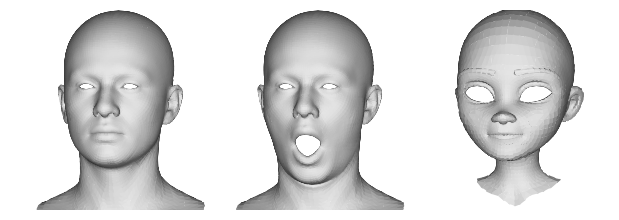

In [26]:
## full head
ict_face_model = ICT_face_model()
ict_tri = ict_face_model.get_mesh()

############################################
## flame
flame_tri = trimesh.load(f'{abs_path}/test-mesh/flame_final_transformed.obj', process=False, maintain_order=True)
# flame_tri = trimesh.load(f'{abs_path}/test-mesh/biwi_M5.obj', process=False, maintain_order=True)
# flame_tri = trimesh.load(f'{abs_path}/test-mesh/biwi_M5_deci.obj', process=False, maintain_order=True)
print(flame_tri.vertices.shape)
############################################

############################################
flame_tri = trimesh.load(f'{abs_path}/test-mesh/mary-align.obj', process=False, maintain_order=True)
flame_tri.vertices = flame_tri.vertices + np.array([[0, -0.05, -0.35]])
############################################

## ICT random expression
bs_coeff = np.eye(53)[26]
# bs_coeff = np.eye(53)[51] + np.eye(53)[52] + np.eye(53)[26]*0.5
# vertices = torch.from_numpy(ict_tri.vertices + ict_face_model.get_exp_disp(bs_coeff))
vertices = ict_tri.vertices + ict_face_model.get_exp_disp(bs_coeff)
src_mesh = ict_tri
tgt_mesh = flame_tri


print(ict_tri.vertices.shape)


M_SCALE = 0.68
v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE ]
f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces ]
SIZE=2

plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"_tmp/train", 
    name=f"test", save=False
)

In [27]:
device=trainer.device
print(device)

sd_v = ict_tri.vertices + ict_face_model.get_exp_disp(bs_coeff).squeeze(0)
# print(sd_v.shape)
s_v_B_th = torch.from_numpy(ict_tri.vertices)[None].float().to(device)
s_n_B_th = torch.from_numpy(igl.per_vertex_normals(ict_tri.vertices, ict_tri.faces))[None].float().to(device)
sd_v_B_th = torch.from_numpy(sd_v)[None].float().to(device)
sd_n_B_th = torch.from_numpy(igl.per_vertex_normals(sd_v, ict_tri.faces))[None].float().to(device)
t_v_B_th = torch.from_numpy(tgt_mesh.vertices)[None].float().to(device)
t_n_B_th = torch.from_numpy(igl.per_vertex_normals(tgt_mesh.vertices, tgt_mesh.faces))[None].float().to(device)

pred_outputs, pred_source, exp_z_d, key_d, exp_z_s, key_s, key_weight = trainer.model.retarget(
    s_v_B_th, s_n_B_th, sd_v_B_th, sd_n_B_th, t_v_B_th, t_n_B_th, mesh_data=0, out_kw=True
)



# device=trainer.device
# print(device)

# sd_v = vertices.squeeze(0)

# s_v_B_th = torch.from_numpy(src_mesh.vertices)[None].float().to(device)
# sd_v_B_th = torch.from_numpy(sd_v)[None].float().to(device)
# t_v_B_th = torch.from_numpy(tgt_mesh.vertices)[None].float().to(device)

# trainer.model.eval()
# pred_outputs, pred_source, key_d, key_s, key_weight = trainer.model.retarget(
#     s_v_B_th, sd_v_B_th, t_v_B_th, out_kw=True
# )


cuda:0


In [28]:
key_weight.detach().cpu().numpy()[0].max()
# key_weight.min()

0.031523813

 source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


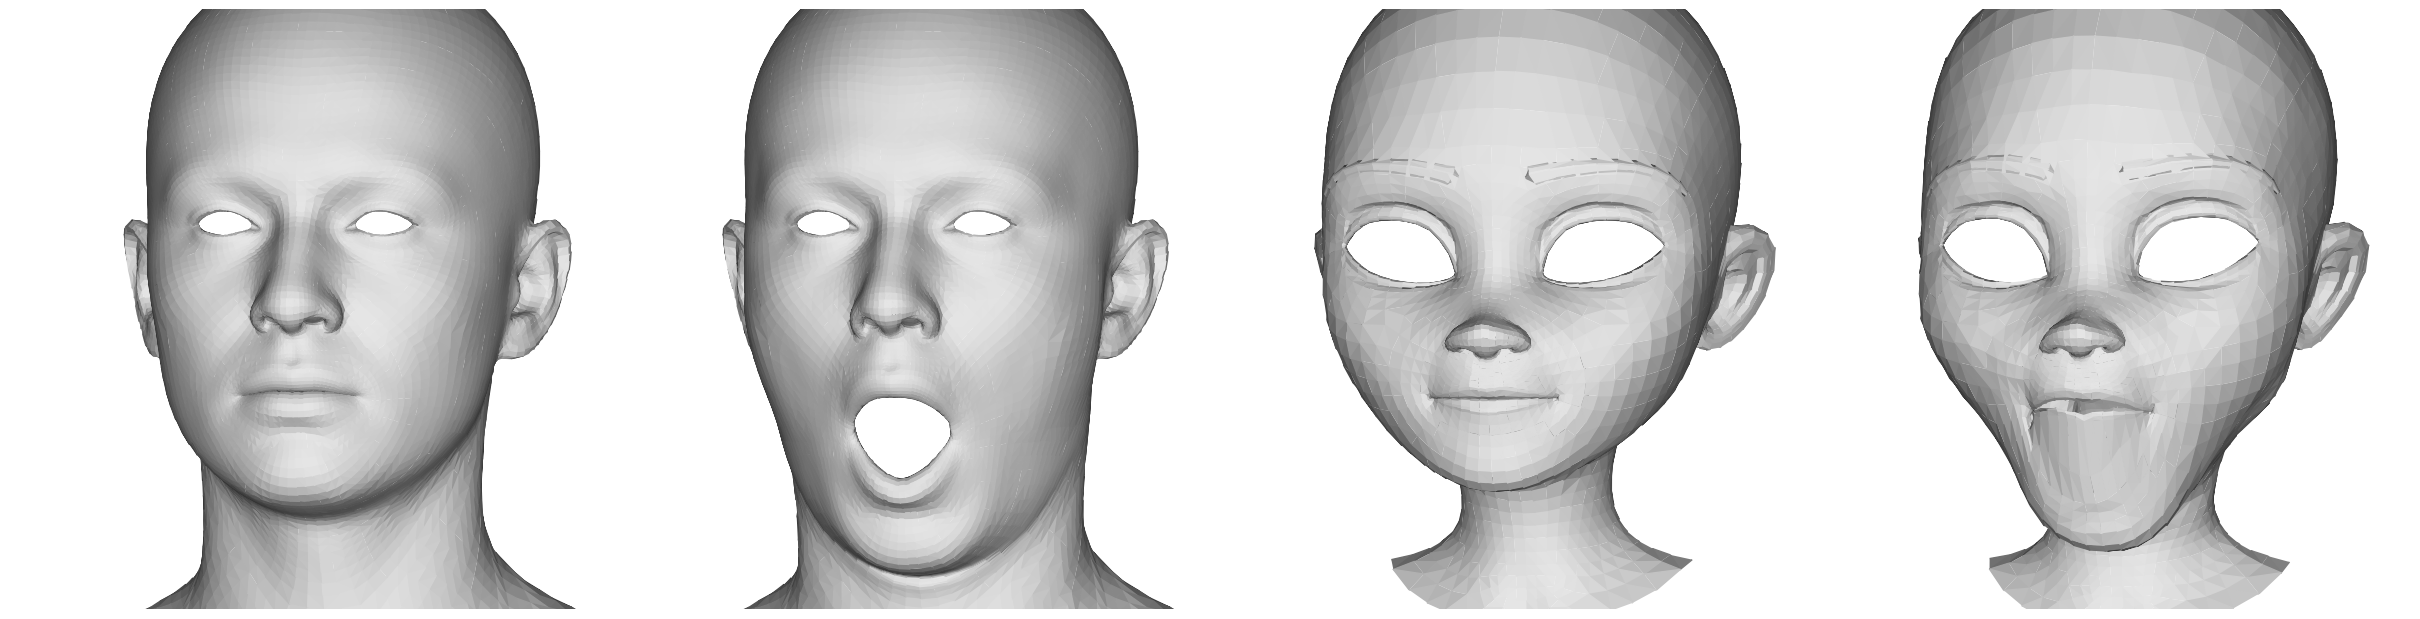

In [29]:
SIZE=6
M_SCALE=.82
SAVE=0

M_trns=np.array([0,0.,0])
v_list=[
    src_mesh.vertices,
    vertices[0],
    tgt_mesh.vertices,
    pred_outputs.detach().cpu().numpy()[0]
]
v_list = [v * M_SCALE + M_trns for v in v_list]
f_list=[ src_mesh.faces, src_mesh.faces, tgt_mesh.faces, tgt_mesh.faces ]

print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"../_tmp", 
    name=f"NeuralCage-retarget", save=SAVE
)

In [12]:
import torch
import torch.nn as nn
from MAASA.models.wav2rig import Wav2Rig
import librosa

class Options:
    def __init__(self):
        self.input_dim=768
        self.feat_dim=128
        self.feat_level='05'
        self.rig_dim=128
        self.fps=30
        self.model_type='conv'
        self.style_emb=True
        self.use_three=True
        self.device='cuda'
        self.ckpt_path=f'{__maasa_path__}/MAASA/ckpt_stage1/2026-01-30-02-05-05/wav2rig_best.pth'
        return
    
class Inference(nn.Module):
    def __init__(self, opts, audio_model_type="wav2vec2"):
        super(Inference, self).__init__()
        # set opts
        self.opts = opts
        self.device = opts.device
        
        # model load
        self.model = Wav2Rig( \
            opts.input_dim * 12 if opts.feat_level=='all' else opts.input_dim, \
            opts.feat_dim, \
            opts.rig_dim, \
            model_type=opts.model_type, \
            style_emb=opts.style_emb, \
            use_three=opts.use_three
        ).to(self.device)
        
        # audio handler
        from MAASA.data_capture.audio_preprocess_wave2vec2 import AudioHandler
        self.audio_handler = AudioHandler(self.device, model_type=audio_model_type)
        self.load()
        self.model.eval()
        
    def load(self):
        try:
            state_dict = torch.load(self.opts.ckpt_path)
            self.model.load_state_dict(state_dict)
            print('loaded ckpt succesfully!')
        except:
            raise ValueError(f"Failed to load {self.opts.ckpt_path}")

    def forward(self, wav_file, frame_num=None, id_label=None):
        # predict
        if type(wav_file) == str:
            feats, logits = self.audio_handler.inference(wav_file, frame_num)
            if self.opts.feat_level == "logits":
                audio = logits
            elif self.opts.feat_level == "all":
                # import pdb;pdb.set_trace()
                audio = np.stack(feats).transpose(1,2,0)
                audio = audio.reshape(audio.shape[0], -1)
            else:
                audio = feats[int(self.opts.feat_level)]
            # to torch
            audio = torch.from_numpy(audio).to(self.device).float()
            audio = audio.unsqueeze(0)
        elif type(wav_file) == torch.Tensor:
            audio = wav_file.to(self.device).float()
        elif type(wav_file) == np.ndarray:
            audio = torch.from_numpy(wav_file).to(self.device).float()
        if torch.is_tensor(id_label):
            id_label = id_label.to(self.device)
        pred_rig = self.model(audio, input_fps=self.opts.fps, target_fps=self.opts.fps, \
            frame_num=frame_num, one_hot=id_label)
        return pred_rig
    
    @torch.no_grad()
    def infer(self, wav_file, frame_num=None, id_label=None):
        return self.forward(wav_file, frame_num, id_label)

In [16]:
# audio_fn='/source/sihun/MAASA/demo/test.wav'
audio_fn=f'{__maasa_path__}/MAASA/demo/test.wav'
# audio_fn=f'{__maasa_path__}/demo/man.wav'
save_video_name="demo_test-bonnie-s03-nfs_eg2025"
# save_video_name="demo_test-voca_test-s02-nfs_eg2025"
# save_video_name="demo_man-mf_test-nfs_eg2025"
save_pred_dir=f'{__maasa_path__}/MAASA/demo/tmp'
save_video_dir=f'{__maasa_path__}/MAASA/demo'

torch.cuda.empty_cache()

In [17]:
## loading wav2rig
opt = Options()
pipeline = Inference(opt)

Sample Rate: 16000
Labels: ('-', '|', 'E', 'T', 'A', 'O', 'N', 'I', 'H', 'S', 'R', 'D', 'L', 'U', 'M', 'W', 'C', 'F', 'G', 'Y', 'P', 'B', 'V', 'K', "'", 'X', 'J', 'Q', 'Z')
loaded ckpt succesfully!


In [18]:
import time

# dummy label
dummy_label = torch.eye(20)[2][None].long()
# dummy_label = torch.eye(20)[3][None].long()
# dummy_label = torch.eye(20)[0][None].long()

st = time.time()
## rig prediction
z0_pred = pipeline.infer(audio_fn, None, id_label=dummy_label)
print(f"[Eval] Inference time: {time.time() - st}")

T = z0_pred.shape[1]

z0_pred = z0_pred.squeeze(0)
z0_pred = z0_pred - z0_pred.mean(0)[None]*0.5
print(z0_pred.shape, z0_pred.device)

[Eval] Inference time: 0.6889955997467041
torch.Size([346, 128]) cuda:0


In [22]:
pred_outputs, key_d = trainer.model.blendshape(
    exp_z = z0_pred.unsqueeze(1), 
    key_weight=key_weight,
)

In [23]:
pred_outputs.shape

torch.Size([346, 23370, 3])

 source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


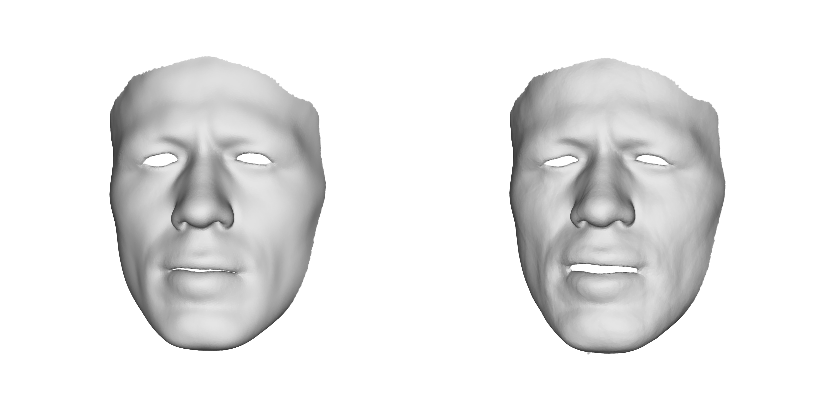

In [28]:
SIZE=4
M_SCALE=.82
SAVE=0
FRAME=200

M_trns=np.array([0,0.,0])
v_list=[ 
    tgt_mesh.vertices, 
    pred_outputs[FRAME].detach().cpu().numpy() 
]
v_list = [v * M_SCALE + M_trns for v in v_list]
f_list=[ tgt_mesh.faces, tgt_mesh.faces ]

print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"../_tmp", 
    name=f"NeuralCage-retarget", save=SAVE
)

In [29]:
import time
import subprocess
import os
from tqdm import tqdm
try:
    import fire
except:
    !pip install fire

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [ ]:
os.makedirs(save_pred_dir, exist_ok=True)

input_template_mesh = face_mesh
mesh_transformed_pred_v = pred_outputs

for i, mesh_v in tqdm(enumerate(mesh_transformed_pred_v.detach().cpu())):
    tmp_mesh = trimesh.Trimesh(vertices=mesh_v, faces=input_template_mesh.faces)
#     tmp_mesh.vertices = tmp_mesh.vertices[:len(ict_face_mesh_nf.vertices)]
#     tmp_mesh.faces = ict_face_mesh_nf.faces
    _ = tmp_mesh.export(f'{save_pred_dir}/{i:03d}.obj')

 source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


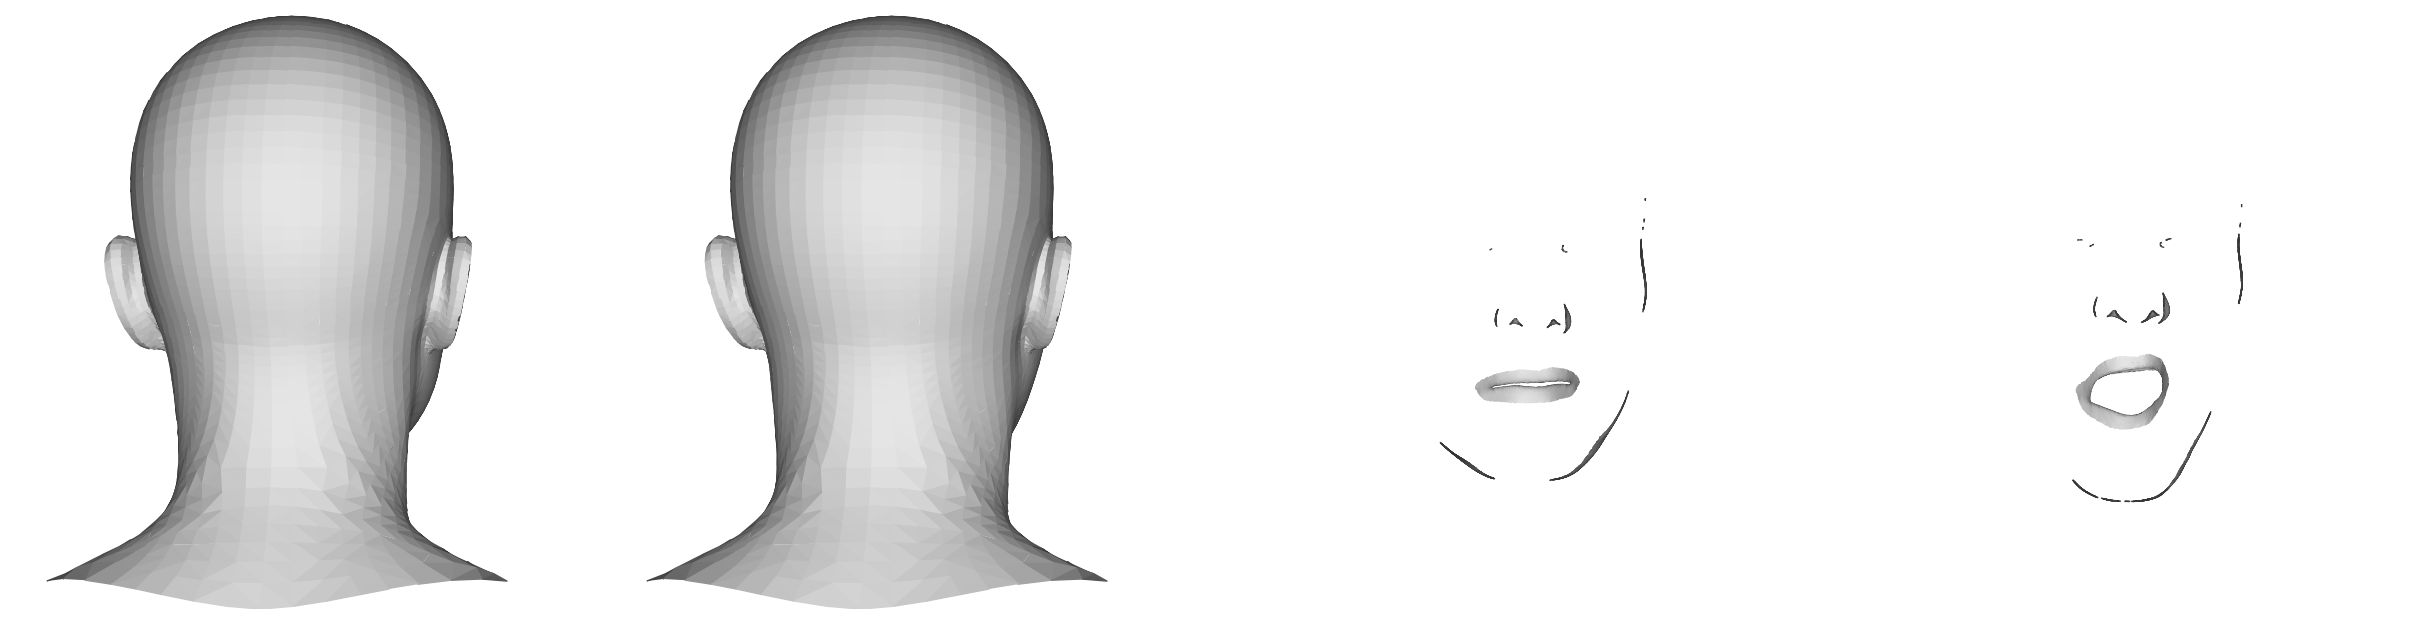

 source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


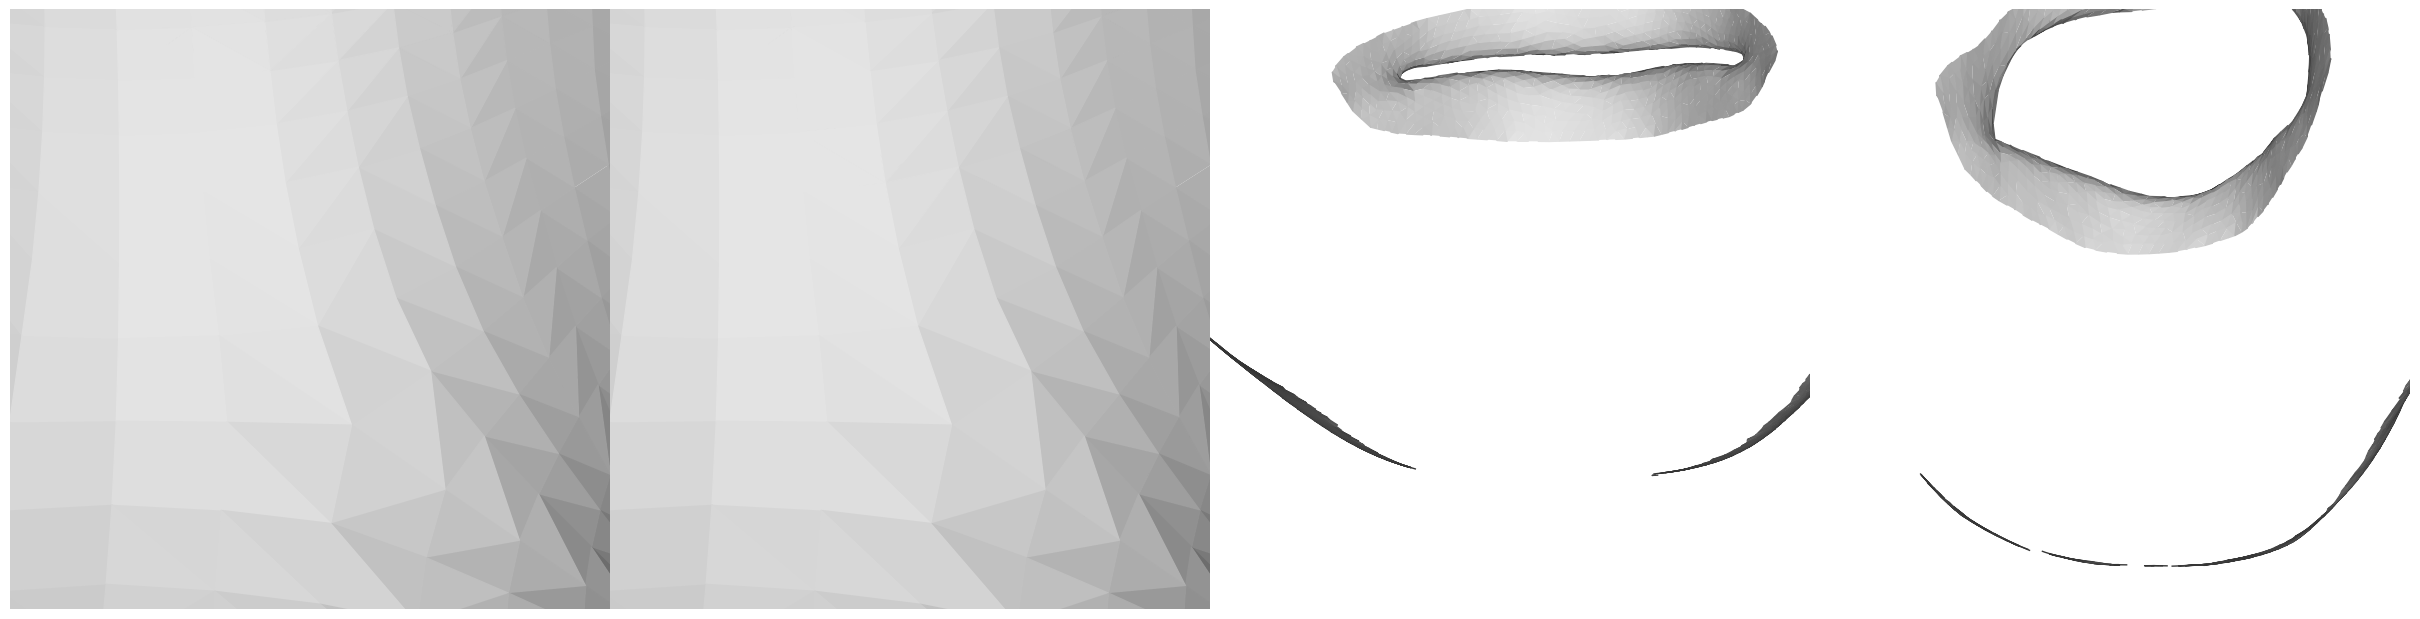

In [70]:
SIZE=6
M_SCALE=.82
SAVE=0

M_trns=np.array([0,0.,0])
v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE, pred_outputs.detach().cpu().numpy()[0] * M_SCALE ]
v_list = [v * M_SCALE + M_trns for v in v_list]
f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces, flame_tri.faces ]

print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_image_array(
    v_list, f_list,
    rot_list=[[0,-190,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"../_tmp", 
    name=f"NBC-retarget", save=SAVE
)

M_SCALE=1.7
M_trns=np.array([0.1, 1.9, 0])
v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE, pred_outputs.detach().cpu().numpy()[0] * M_SCALE ]
v_list = [v * M_SCALE + M_trns for v in v_list]
f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces, flame_tri.faces ]

print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_image_array(
    v_list, f_list,
    rot_list=[[0,-190,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"../_tmp", 
    name=f"NBC-retarget-zoom", save=SAVE
)